In [1]:
#pip install plotly

In [2]:
#pip install statsmodels prophet tensorflow scikit-learn

In [3]:
#pip install bottleneck numexpr

In [4]:
#pip install openpyxl

In [5]:
import warnings
warnings.filterwarnings("ignore")

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler



In [9]:
df = pd.read_excel("PJMW_MW_Hourly.xlsx")

In [10]:
df

,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077
1,2002-12-31 02:00:00,4939
2,2002-12-31 03:00:00,4885
3,2002-12-31 04:00:00,4857
4,2002-12-31 05:00:00,4930
...,...,...
143201,2018-01-01 20:00:00,8401
143202,2018-01-01 21:00:00,8373
143203,2018-01-01 22:00:00,8238
143204,2018-01-01 23:00:00,7958


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  143206 non-null  datetime64[us]
 1   PJMW_MW   143206 non-null  int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 2.2 MB


In [12]:
df.describe()

,Datetime,PJMW_MW
count,143206,143206.000000
mean,2010-06-02 03:39:50.656815,5602.375089
min,2002-04-01 01:00:00,487.000000
25%,2006-05-02 03:15:00,4907.000000
50%,2010-06-02 04:30:00,5530.000000
75%,2014-07-03 06:45:00,6252.000000
max,2018-08-03 00:00:00,9594.000000
std,NaN,979.142872


In [13]:
df.shape

(143206, 2)

143,206 hourly observations

That’s roughly 16+ years of data

Data spans 2002 → 2018

Long historical window → excellent for trend & seasonality learning

On average, PJM consumes ~5600 MW per hour

Datetime correctly parsed

Target variable is numeric

“We have a clean hourly time-series dataset spanning over 16 years with no missing values. The energy consumption shows significant variability, indicating strong hourly and seasonal patterns, making it suitable for advanced time-series forecasting.”

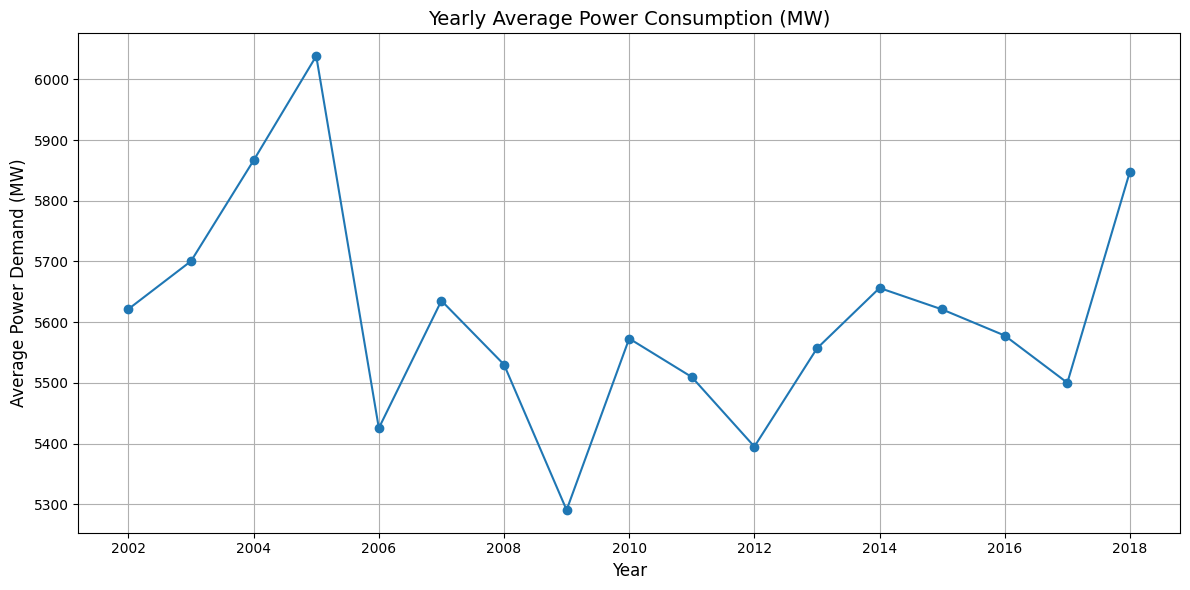

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Load Dataset
# -------------------------------
df = pd.read_excel("PJMW_MW_Hourly.xlsx")  # change if needed

# -------------------------------
# Data Preprocessing
# -------------------------------
df['Datetime'] = pd.to_datetime(df['Datetime'])   # ensure datetime format
df['Year'] = df['Datetime'].dt.year               # extract year

# -------------------------------
# EDA: Average MW per Year
# -------------------------------
avg_mw_yearly = df.groupby('Year')['PJMW_MW'].mean().reset_index()

# -------------------------------
# Visualization
# -------------------------------
plt.figure(figsize=(12,6))

plt.plot(
    avg_mw_yearly['Year'],
    avg_mw_yearly['PJMW_MW'],
    marker='o'
)

# Proper naming
plt.title("Yearly Average Power Consumption (MW)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Power Demand (MW)", fontsize=12)

plt.grid()
plt.tight_layout()

# Save graph (optional)
plt.savefig("yearly_avg_mw.png", dpi=300, bbox_inches='tight')

plt.show()

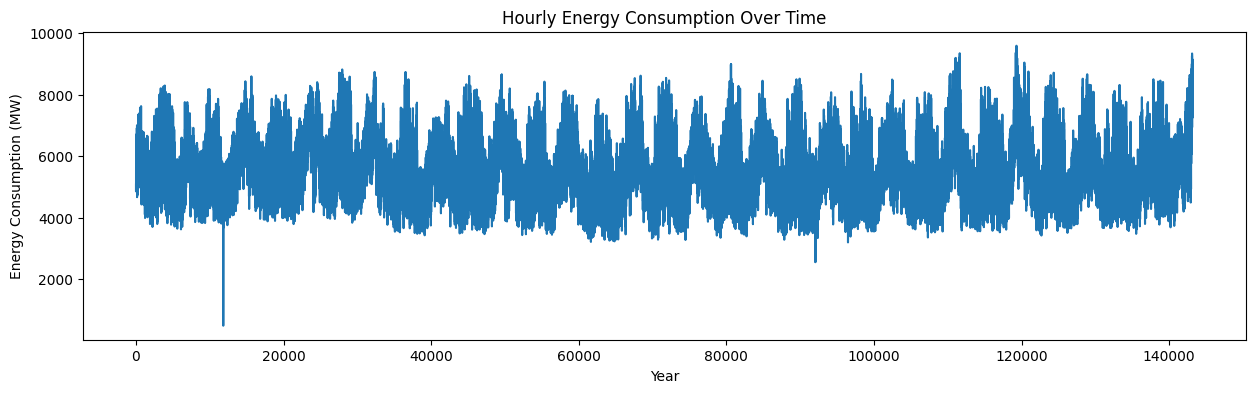

In [14]:
plt.figure(figsize=(15,4))
plt.plot(df.index, df['PJMW_MW'])
plt.title("Hourly Energy Consumption Over Time")
plt.xlabel("Year")
plt.ylabel("Energy Consumption (MW)")
plt.show()

Electricity consumption shows strong recurring patterns over time, indicating clear daily and seasonal cycles.

The consistent repetition of peaks and troughs suggests demand is predictable and suitable for time-series forecasting.

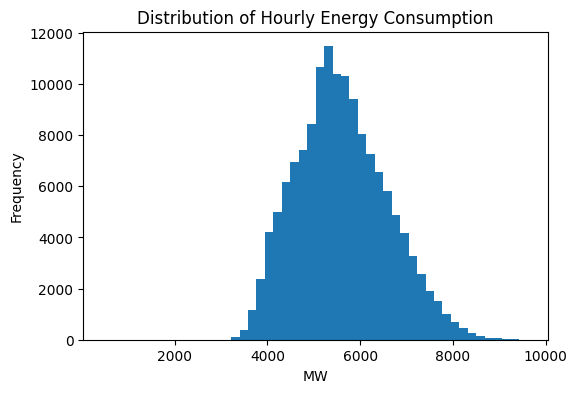

In [15]:
plt.figure(figsize=(6,4))
plt.hist(df['PJMW_MW'], bins=50)
plt.title("Distribution of Hourly Energy Consumption")
plt.xlabel("MW")
plt.ylabel("Frequency")
plt.show()

Most hourly electricity consumption values lie within a stable range, with fewer extreme high-demand hours.

The presence of a right tail highlights critical peak-load periods that require accurate forecasting.

In [16]:
df.head()

,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077
1,2002-12-31 02:00:00,4939
2,2002-12-31 03:00:00,4885
3,2002-12-31 04:00:00,4857
4,2002-12-31 05:00:00,4930


In [17]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime')
df.set_index('Datetime', inplace=True)

In [18]:
dff=df.copy()

In [19]:
dff

,PJMW_MW
Datetime,
2002-04-01 01:00:00,4374
2002-04-01 02:00:00,4306
2002-04-01 03:00:00,4322
2002-04-01 04:00:00,4359
2002-04-01 05:00:00,4436
...,...
2018-08-02 20:00:00,6545
2018-08-02 21:00:00,6496
2018-08-02 22:00:00,6325


In [20]:
type(df.index)

pandas.DatetimeIndex

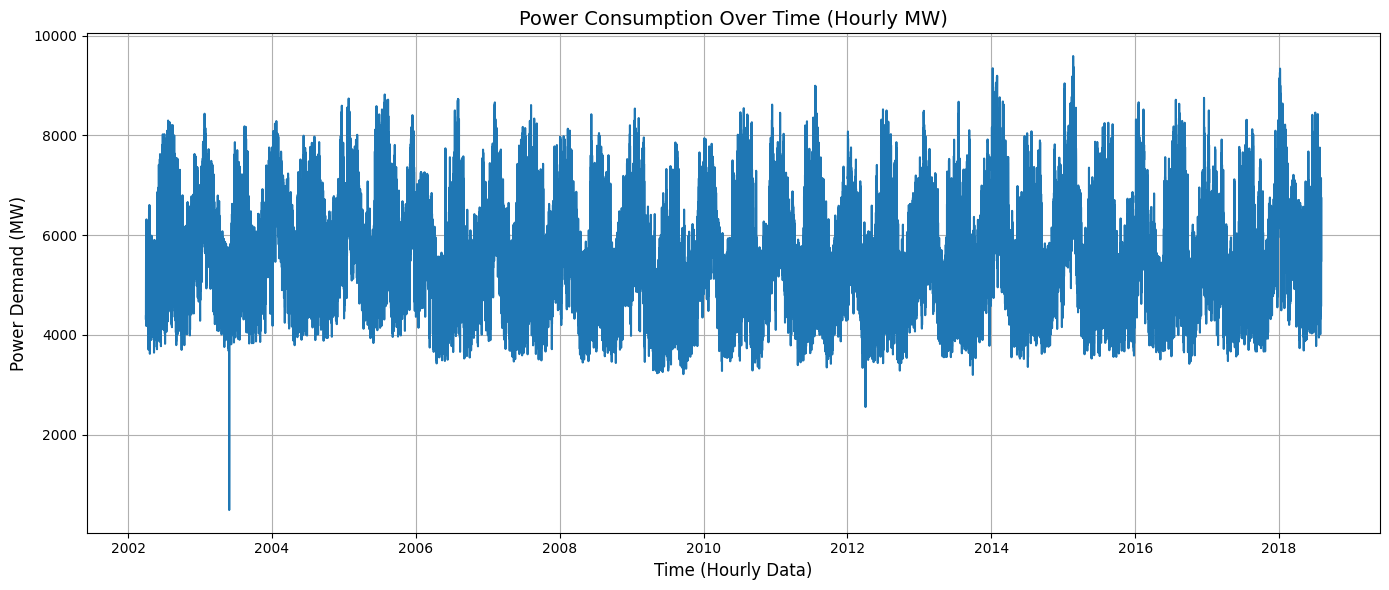

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Load Dataset
# -------------------------------
df = pd.read_excel("PJMW_MW_Hourly.xlsx")

# -------------------------------
# Data Preprocessing
# -------------------------------
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Sort data (important for time series)
df = df.sort_values(by='Datetime')

# -------------------------------
# Visualization: MW vs Time (Hourly)
# -------------------------------
plt.figure(figsize=(14,6))

plt.plot(
    df['Datetime'],
    df['PJMW_MW']
)

# Proper naming
plt.title("Power Consumption Over Time (Hourly MW)", fontsize=14)
plt.xlabel("Time (Hourly Data)", fontsize=12)
plt.ylabel("Power Demand (MW)", fontsize=12)

plt.grid()
plt.tight_layout()

# Save graph (optional)
plt.savefig("mw_vs_time_hourly.png", dpi=300, bbox_inches='tight')

plt.show()

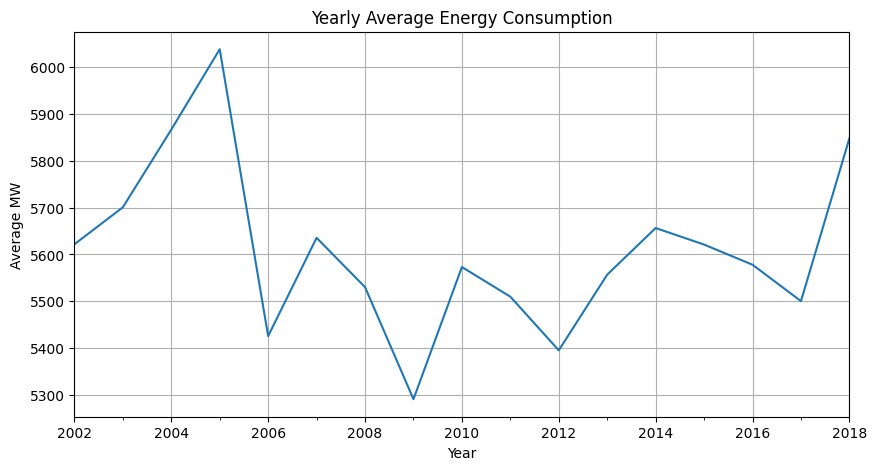

In [21]:
# Yearly average energy consumption (Year-End frequency)
yearly_avg = df['PJMW_MW'].resample('YE').mean()

plt.figure(figsize=(10,5))
yearly_avg.plot()
plt.title("Yearly Average Energy Consumption")
plt.xlabel("Year")
plt.ylabel("Average MW")
plt.grid(True)
plt.show()

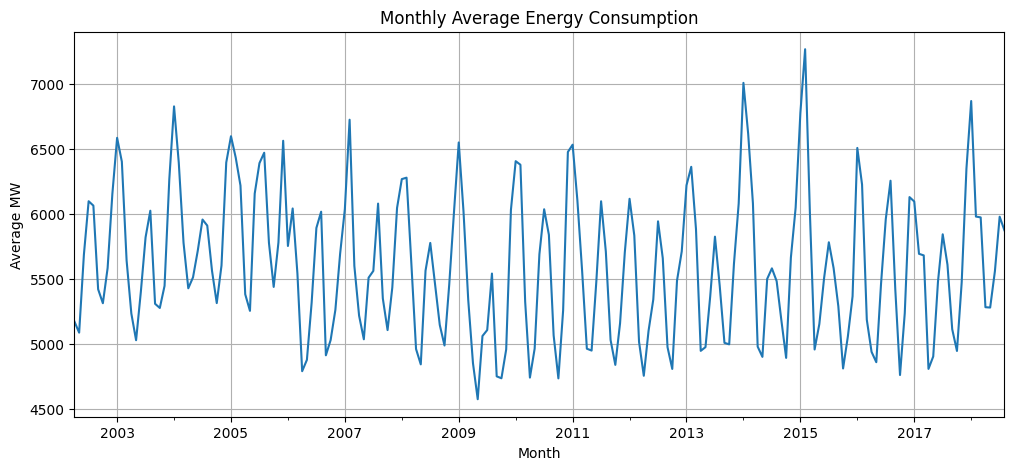

In [22]:
monthly_avg = df['PJMW_MW'].resample('ME').mean()

plt.figure(figsize=(12,5))
monthly_avg.plot()
plt.title("Monthly Average Energy Consumption")
plt.xlabel("Month")
plt.ylabel("Average MW")
plt.grid(True)
plt.show()

In [23]:
df_eda = df.copy()

df_eda['hour'] = df_eda.index.hour
df_eda['day'] = df_eda.index.day
df_eda['month'] = df_eda.index.month
df_eda['dayofweek'] = df_eda.index.dayofweek
df_eda['year'] = df_eda.index.year

In [24]:
df_eda[['PJMW_MW','hour','month','dayofweek']].head()

,PJMW_MW,hour,month,dayofweek
Datetime,,,,
2002-04-01 01:00:00,4374,1,4,0
2002-04-01 02:00:00,4306,2,4,0
2002-04-01 03:00:00,4322,3,4,0
2002-04-01 04:00:00,4359,4,4,0
2002-04-01 05:00:00,4436,5,4,0


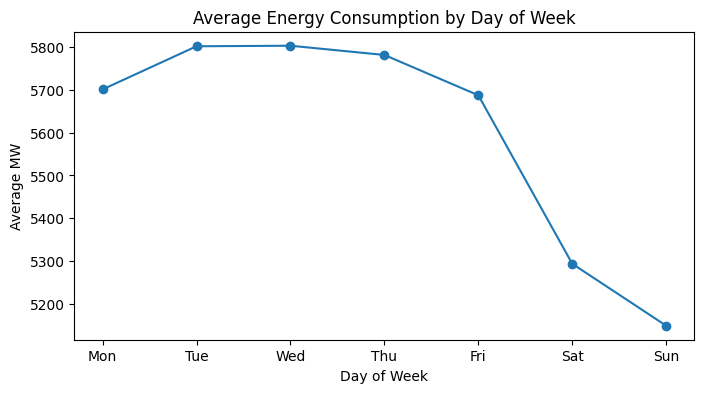

In [25]:
dow_avg = df_eda.groupby('dayofweek')['PJMW_MW'].mean()

plt.figure(figsize=(8,4))
plt.plot(dow_avg.index, dow_avg.values, marker='o')
plt.xticks(range(7), ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.title("Average Energy Consumption by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average MW")
plt.show()

Electricity demand is higher on weekdays compared to weekends due to increased commercial and industrial activity.

Demand drops significantly on Saturdays and Sundays, reflecting reduced business operations.

In [26]:
df_eda['is_weekend'] = df_eda['dayofweek'].isin([5,6])

In [27]:
df_eda.groupby('is_weekend')['PJMW_MW'].mean()

is_weekend
False    5754.345669
True     5221.863008
Name: PJMW_MW, dtype: float64

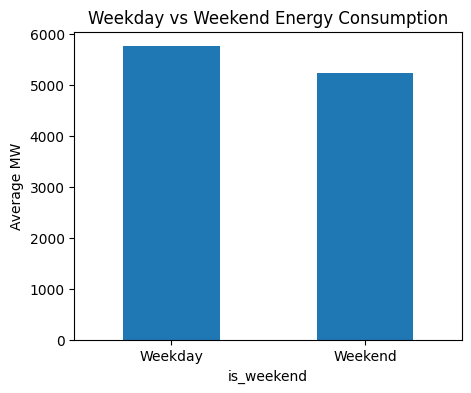

In [28]:
week_avg = df_eda.groupby('is_weekend')['PJMW_MW'].mean()

plt.figure(figsize=(5,4))
week_avg.plot(kind='bar')
plt.xticks([0,1], ['Weekday','Weekend'], rotation=0)
plt.title("Weekday vs Weekend Energy Consumption")
plt.ylabel("Average MW")
plt.show()

Average electricity consumption is noticeably higher on weekdays than on weekends.

This consistent difference indicates predictable demand behavior useful for operational planning and maintenance scheduling.

“The exploratory data analysis shows that hourly energy consumption follows strong daily, weekly, and seasonal patterns. Demand is higher during business hours and weekdays, while weekends show reduced consumption. These clear temporal patterns justify the use of time-series forecasting models.”

### EDA – Step 3: Monthly & Seasonal Trends

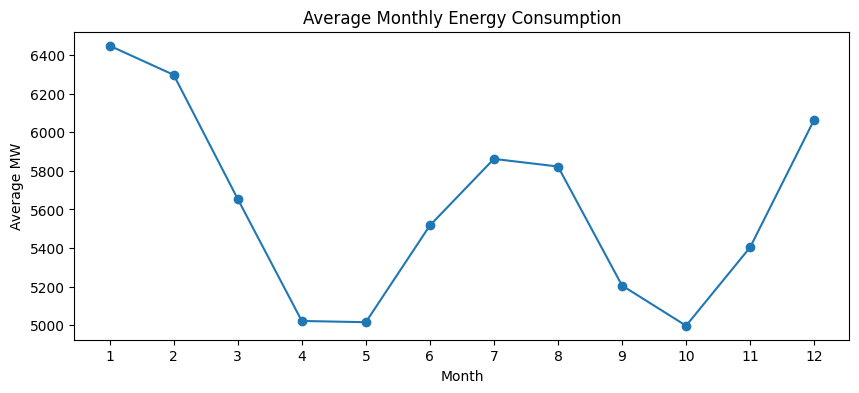

In [29]:
monthly_avg = df_eda.groupby('month')['PJMW_MW'].mean()

plt.figure(figsize=(10,4))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o')
plt.xticks(range(1,13))
plt.title("Average Monthly Energy Consumption")
plt.xlabel("Month")
plt.ylabel("Average MW")
plt.show()

Monthly electricity consumption exhibits strong seasonality, with higher demand during winter and summer months.

Lower consumption during spring and fall reflects reduced heating and cooling requirements.

In [30]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df_eda['season'] = df_eda['month'].apply(get_season)

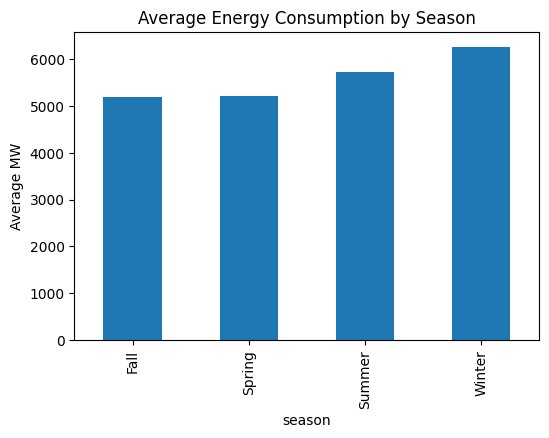

In [31]:
season_avg = df_eda.groupby('season')['PJMW_MW'].mean()

plt.figure(figsize=(6,4))
season_avg.plot(kind='bar')
plt.title("Average Energy Consumption by Season")
plt.ylabel("Average MW")
plt.show()

Winter records the highest average electricity consumption, followed by summer.

Seasonal demand variations highlight the importance of incorporating seasonality into forecasting models.

In [32]:
season_hourly = (
    df_eda[df_eda['season'].isin(['Summer', 'Winter'])]
    .groupby(['season', 'hour'])['PJMW_MW']
    .mean()
    .reset_index()
)

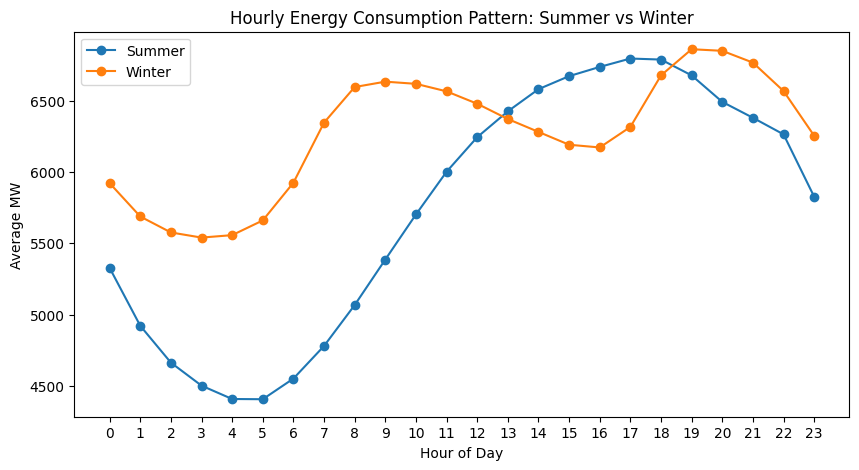

In [33]:
plt.figure(figsize=(10,5))

for season in ['Summer', 'Winter']:
    temp = season_hourly[season_hourly['season'] == season]
    plt.plot(temp['hour'], temp['PJMW_MW'], marker='o', label=season)

plt.xticks(range(0,24))
plt.xlabel("Hour of Day")
plt.ylabel("Average MW")
plt.title("Hourly Energy Consumption Pattern: Summer vs Winter")
plt.legend()
plt.show()

Summer demand shows sharp afternoon and evening peaks driven by cooling needs, while winter demand is more evenly distributed across the day.

The differing hourly patterns across seasons confirm that demand behavior changes significantly with seasonal conditions.

“Electricity demand shows strong monthly seasonality, with higher consumption during winter and summer months due to heating and cooling requirements.”

“Winter has the highest electricity consumption followed by summer, indicating strong seasonal dependency driven by heating and cooling needs.

“Hourly electricity consumption patterns differ significantly between summer and winter, with summer showing sharp afternoon peaks and winter exhibiting more distributed demand across the day.”

<Figure size 1200x500 with 0 Axes>

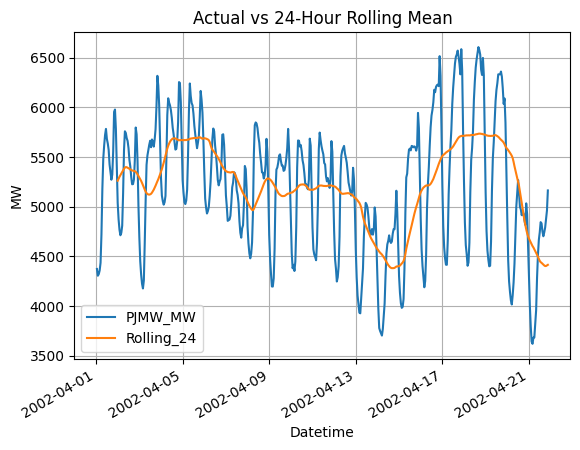

In [34]:
df['Rolling_24'] = df['PJMW_MW'].rolling(window=24).mean()

plt.figure(figsize=(12,5))
df[['PJMW_MW', 'Rolling_24']].iloc[:500].plot()
plt.title("Actual vs 24-Hour Rolling Mean")
plt.ylabel("MW")
plt.grid(True)
plt.show()

<Figure size 1200x500 with 0 Axes>

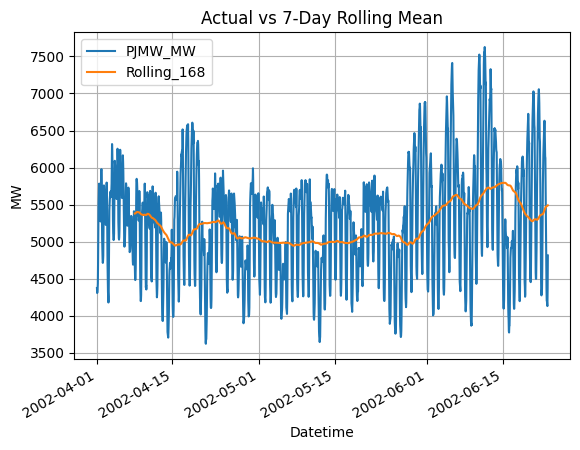

In [35]:
df['Rolling_168'] = df['PJMW_MW'].rolling(window=168).mean()

plt.figure(figsize=(12,5))
df[['PJMW_MW', 'Rolling_168']].iloc[:2000].plot()
plt.title("Actual vs 7-Day Rolling Mean")
plt.ylabel("MW")
plt.grid(True)
plt.show()

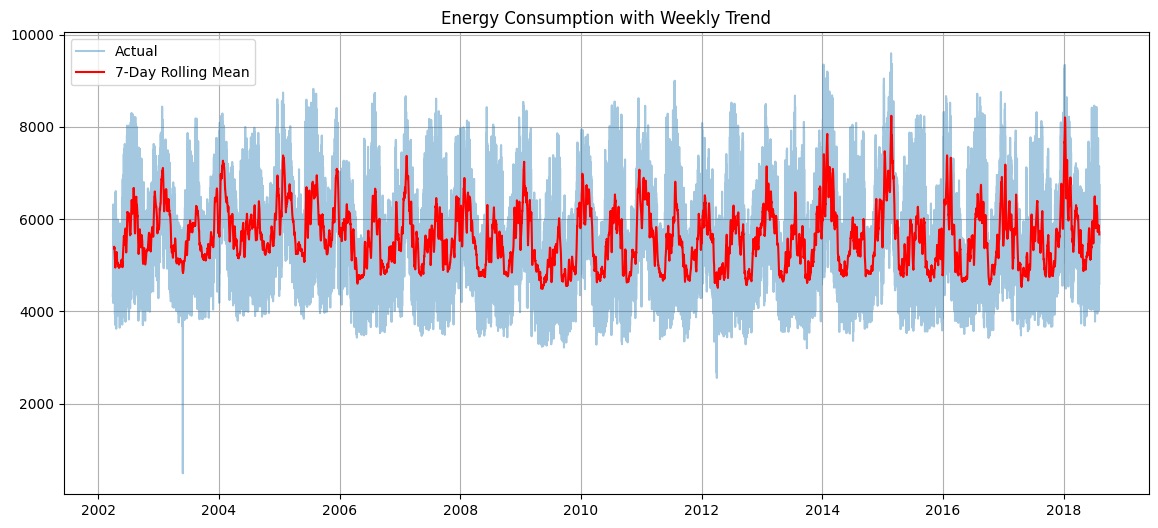

In [36]:
plt.figure(figsize=(14,6))
plt.plot(df['PJMW_MW'], alpha=0.4, label='Actual')
plt.plot(df['Rolling_168'], color='red', label='7-Day Rolling Mean')
plt.title("Energy Consumption with Weekly Trend")
plt.legend()
plt.grid(True)
plt.show()

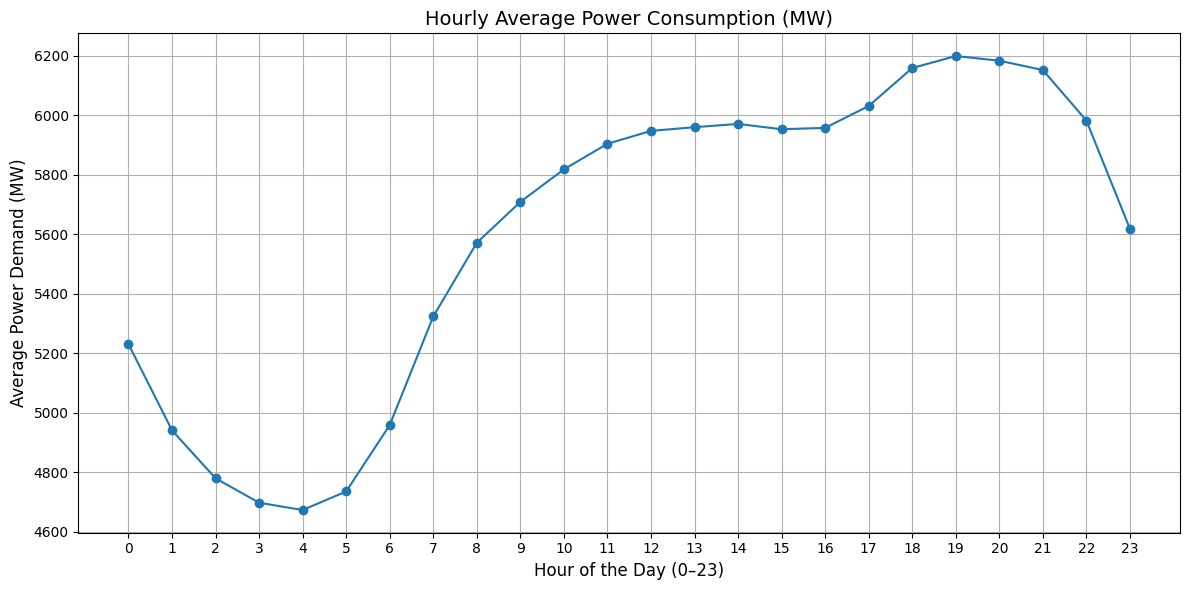

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Load Dataset
# -------------------------------
df = pd.read_excel("PJMW_MW_Hourly.xlsx")  # change if needed

# -------------------------------
# Data Preprocessing
# -------------------------------
df['Datetime'] = pd.to_datetime(df['Datetime'])   # ensure datetime format
df['Hour_of_Day'] = df['Datetime'].dt.hour        # extract hour

# -------------------------------
# EDA: Average MW per Hour
# -------------------------------
avg_mw_hourly = df.groupby('Hour_of_Day')['PJMW_MW'].mean().reset_index()

# -------------------------------
# Visualization
# -------------------------------
plt.figure(figsize=(12,6))

plt.plot(
    avg_mw_hourly['Hour_of_Day'],
    avg_mw_hourly['PJMW_MW'],
    marker='o'
)

# Proper naming
plt.title("Hourly Average Power Consumption (MW)", fontsize=14)
plt.xlabel("Hour of the Day (0–23)", fontsize=12)
plt.ylabel("Average Power Demand (MW)", fontsize=12)

plt.xticks(range(0, 24))  # show all hours
plt.grid()

plt.tight_layout()
plt.show()

**Conclusion for EDA**

“Exploratory Data Analysis reveals strong hourly, weekly, monthly, and seasonal patterns in electricity consumption. Demand is higher during weekdays, peaks in summer and winter seasons, and exhibits distinct hourly behavior across seasons. These findings confirm that energy consumption is highly time-dependent and seasonal, making time-series forecasting models appropriate.”

In [ ]:
df_eda

In [ ]:
df_eda.tail()

In [ ]:
df_eda.info()

In [ ]:
df_dl = df_eda.copy()

# Convert boolean
df_dl['is_weekend'] = df_dl['is_weekend'].astype(int)

# One-hot encode season
df_dl = pd.get_dummies(df_dl, columns=['season'], drop_first=True)

# Sort by datetime
df_dl = df_dl.sort_index()

print(df_dl.head())

In [ ]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df_dl)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=df_dl.columns,
    index=df_dl.index
)

In [ ]:
def create_sequences(data, target_col, seq_len):

    X = []
    y = []

    target_index = data.columns.get_loc(target_col)

    for i in range(len(data) - seq_len):

        X.append(data.iloc[i:i+seq_len].values)
        y.append(data.iloc[i+seq_len, target_index])

    return np.array(X), np.array(y)

SEQ_LEN = 24

X, y = create_sequences(scaled_df, 'PJMW_MW', SEQ_LEN)

print(X.shape, y.shape)

In [ ]:
df

In [ ]:
dff.head()

In [ ]:
# ensure datetime index
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# remove duplicates
df = df[~df.index.duplicated(keep='first')]

# set hourly frequency
df = df.asfreq('h')

# fill missing values
df['PJMW_MW'] = df['PJMW_MW'].interpolate()

ts = df[['PJMW_MW']]

In [ ]:
train_size = int(len(ts) * 0.8)

train = ts.iloc[:train_size]
test = ts.iloc[train_size:]

y_train = train['PJMW_MW']
y_test = test['PJMW_MW']

print("Train size:", len(train))
print("Test size:", len(test))

In [ ]:
def evaluate(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"\n{name}")
    print("MAE:", mae)
    print("RMSE:", rmse)

    return rmse

In [ ]:
def show_model_evaluation(model_name, y_true, y_pred, result_row):
    print(f"\n{model_name} - Evaluation Metrics")
    display(pd.DataFrame([result_row]).set_index("Model"))

    plot_len = min(24 * 7, len(y_true))
    plt.figure(figsize=(14, 4))
    plt.plot(y_true.index[:plot_len], y_true.values[:plot_len], label="Actual", linewidth=1.8)
    plt.plot(y_pred.index[:plot_len], y_pred.values[:plot_len], label=f"Predicted ({model_name})", linewidth=1.2)
    plt.title(f"{model_name}: Actual vs Predicted (First 7 Test Days)")
    plt.xlabel("Datetime")
    plt.ylabel("PJMW_MW")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
import matplotlib.pyplot as plt

hours_30_days = 24 * 30
actual = y_test[-hours_30_days:]
time_index = actual.index

In [ ]:
print("\nTraining ARIMA...")

arima_model = ARIMA(y_train, order=(2,1,2))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(len(y_test))

arima_rmse = evaluate("ARIMA", y_test, arima_pred)

In [ ]:
print("\nTraining SARIMA...")

# Reduced seasonal complexity to avoid very long training
sarima_model = SARIMAX(
    y_train,
    order=(1,1,1),
    seasonal_order=(1,0,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit()

sarima_pred = sarima_fit.forecast(len(y_test))

sarima_rmse = evaluate("SARIMA", y_test, sarima_pred)

In [ ]:
print("\nTraining Holt-Winters...")

hw_model = ExponentialSmoothing(
    y_train,
    trend="add",
    seasonal="add",
    seasonal_periods=24
)

hw_fit = hw_model.fit()

hw_pred = hw_fit.forecast(len(y_test))

hw_rmse = evaluate("Holt-Winters", y_test, hw_pred)

In [ ]:
prophet_df = ts.reset_index()
prophet_df.columns = ['ds','y']

train_prophet = prophet_df.iloc[:train_size]
test_prophet = prophet_df.iloc[train_size:]

model = Prophet()

model.fit(train_prophet)

future = model.make_future_dataframe(periods=len(test_prophet), freq='h')

forecast = model.predict(future)

prophet_pred = forecast['yhat'][-len(test_prophet):].values

prophet_rmse = evaluate("Prophet", y_test, prophet_pred)

In [ ]:
train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test_lstm = y[train_size:]

In [ ]:
lstm_model = tf.keras.Sequential()

lstm_model.add(LSTM(64, return_sequences=True))
lstm_model.add(Dropout(0.2))

lstm_model.add(LSTM(32))
lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

lstm_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

In [ ]:
lstm_pred = lstm_model.predict(X_test)

target_index = scaled_df.columns.get_loc("PJMW_MW")

# inverse transform predictions
dummy_pred = np.zeros((len(lstm_pred), scaled_df.shape[1]))
dummy_pred[:, target_index] = lstm_pred.flatten()

lstm_pred_inv = scaler.inverse_transform(dummy_pred)[:, target_index]


# inverse transform true values
dummy_true = np.zeros((len(y_test_lstm), scaled_df.shape[1]))
dummy_true[:, target_index] = y_test_lstm

y_test_inv = scaler.inverse_transform(dummy_true)[:, target_index]


# evaluation
rmse_lstm = np.sqrt(mean_squared_error(y_test_inv, lstm_pred_inv))
mae_lstm = mean_absolute_error(y_test_inv, lstm_pred_inv)

print("LSTM RMSE:", rmse_lstm)
print("LSTM MAE:", mae_lstm)



In [ ]:
lstm_plot = lstm_pred_inv[-hours_30_days:]

plt.figure(figsize=(16,6))
plt.plot(time_index, actual, label="Actual", linewidth=3)
plt.plot(time_index, lstm_plot, label="LSTM Prediction")

plt.title("LSTM: Actual vs Predicted (Last 30 Days)")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (MW)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
input_shape = (X_train.shape[1], X_train.shape[2])

inputs = Input(shape=input_shape)

attention = MultiHeadAttention(
    num_heads=4,
    key_dim=32
)(inputs, inputs)

x = LayerNormalization()(attention + inputs)

x = GlobalAveragePooling1D()(x)

x = Dense(64, activation="relu")(x)

outputs = Dense(1)(x)

transformer_model = Model(inputs, outputs)

transformer_model.compile(
    optimizer='adam',
    loss='mse'
)

transformer_model.summary()

In [ ]:
transformer_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

In [ ]:
trans_pred = transformer_model.predict(X_test)

target_index = scaled_df.columns.get_loc("PJMW_MW")

dummy_pred = np.zeros((len(trans_pred), scaled_df.shape[1]))
dummy_pred[:, target_index] = trans_pred.flatten()

trans_pred_inv = scaler.inverse_transform(dummy_pred)[:, target_index]


rmse_trans = np.sqrt(mean_squared_error(y_test_inv, trans_pred_inv))
mae_trans = mean_absolute_error(y_test_inv, trans_pred_inv)

print("Transformer RMSE:", rmse_trans)
print("Transformer MAE:", mae_trans)



In [ ]:
results = pd.DataFrame({
    "Model":[
        "ARIMA",
        "SARIMA",
        "Holt-Winters",
        "Prophet",
        "LSTM",
        "Transformer"
    ],
    "RMSE":[
        arima_rmse,
        sarima_rmse,
        hw_rmse,
        prophet_rmse,
        rmse_lstm,
        rmse_trans
    ]
})

print(results)

In [ ]:
best_model = results.loc[results['RMSE'].idxmin()]

print("\nBest Model:")
print(best_model)

In [ ]:
results.sort_values("RMSE").plot(
    x="Model",
    y="RMSE",
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Comparison")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# number of hours for 30 days
hours_30_days = 24 * 30

# actual values
actual = y_test[-hours_30_days:]

# classical model predictions
arima_plot = arima_pred[-hours_30_days:]
sarima_plot = sarima_pred[-hours_30_days:]
hw_plot = hw_pred[-hours_30_days:]
prophet_plot = prophet_pred[-hours_30_days:]

# deep learning predictions (already inverse scaled)
lstm_plot = lstm_pred_inv[-hours_30_days:]
trans_plot = trans_pred_inv[-hours_30_days:]

# create time index
time_index = actual.index

plt.figure(figsize=(18,8))

plt.plot(time_index, actual, label="Actual", linewidth=3, color="black")

plt.plot(time_index, arima_plot, label="ARIMA")
plt.plot(time_index, sarima_plot, label="SARIMA")
plt.plot(time_index, hw_plot, label="Holt-Winters")
plt.plot(time_index, prophet_plot, label="Prophet")
plt.plot(time_index, lstm_plot, label="LSTM")
plt.plot(time_index, trans_plot, label="Transformer")

plt.title("Energy Demand Forecast: Actual vs Predicted (Last 30 Days)")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (MW)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import pickle
import numpy as np

# -----------------------------
# Save Scaler
# -----------------------------
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# -----------------------------
# Save LSTM Model
# -----------------------------
lstm_model.save("lstm_model.h5")

# -----------------------------
# Save Evaluation Metrics
# -----------------------------
metrics = {
    "RMSE": rmse_lstm,
    "MAE": mae_lstm
}

with open("metrics.pkl", "wb") as f:
    pickle.dump(metrics, f)

# -----------------------------
# Save Last Sequence (VERY IMPORTANT)
# -----------------------------
last_sequence = X_test[-1]   # last 24 timestep input

np.save("last_sequence.npy", last_sequence)

print("All files saved successfully")

In [ ]:
import pickle

# last timestamp of dataset
last_date = df_eda.index[-1]

with open("last_date.pkl", "wb") as f:
    pickle.dump(last_date, f)

In [ ]:
# save last 7 days of actual data
history_df = df_eda[['PJMW_MW']].tail(24*30)

history_df.to_pickle("history.pkl")